In [1]:
# Acesso à raiz do projeto

import sys
import os

# Caminho até a raiz do projeto
sys.path.append(os.path.abspath("../../"))


In [2]:
# Importação das bibliotecas necessárias

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from modulos.gerais import exibir_resultado, exibir_relatorio_de_classificacao, preparar_wine
from modulos.arvore_de_decisao import executar_arvore_de_decisao, exibir_regras_da_arvore_de_decisao, gerar_grafico_da_arvore_de_decisao


In [3]:
# Importação e exploração dos dados
wine = load_wine()

# Mudança dos target_names para melhorar a legibilidade da saída
wine.target_names = ['vinho_A', 'vinho_B', 'vinho_C']

X, y, feature_names, target_names = preparar_wine(wine)

# Divisão em Treino (70%) e Teste (30%) com semente fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=13, stratify=y
)


In [4]:
(clf, y_pred_arvore_de_decisao, acuracia_arvore_decisao, precisao_arvore_decisao,
revocacao_arvore_decisao, f1_arvore_decisao) = executar_arvore_de_decisao(X_train, y_train, X_test, y_test)


In [5]:
# Exibição dos resultados das métricas usando Árvore de Decisão com Wine
exibir_resultado(
    acuracia_arvore_decisao, precisao_arvore_decisao,
    revocacao_arvore_decisao, f1_arvore_decisao,
    "ÁRVORE DE DECISÃO"
    )


MÉTRICAS DE AVALIAÇÃO - ÁRVORE DE DECISÃO
Acurácia:  0.9259
Precisão:  0.9278
Revocação: 0.9312
F1-Score:  0.9289




In [6]:
# Exibição das Regras Geradas
exibir_regras_da_arvore_de_decisao(clf, feature_names)



REGRAS DA ÁRVORE DE DECISÃO (FORMATO TEXTO):
|--- color_intensity <= 3.82
|   |--- od280/od315_of_diluted_wines <= 3.73
|   |   |--- class: 1
|   |--- od280/od315_of_diluted_wines >  3.73
|   |   |--- class: 0
|--- color_intensity >  3.82
|   |--- flavanoids <= 1.58
|   |   |--- class: 2
|   |--- flavanoids >  1.58
|   |   |--- proline <= 679.00
|   |   |   |--- class: 1
|   |   |--- proline >  679.00
|   |   |   |--- class: 0



In [7]:
# Exibição do relatório de classificação da Árvore de Decisão com Wine
exibir_relatorio_de_classificacao(y_test, y_pred_arvore_de_decisao, target_names)


==================== RELATÓRIO DE CLASSIFICAÇÃO ====================
              precision    recall  f1-score   support

     vinho_A       0.94      0.89      0.91        18
     vinho_B       0.90      0.90      0.90        21
     vinho_C       0.94      1.00      0.97        15

    accuracy                           0.93        54
   macro avg       0.93      0.93      0.93        54
weighted avg       0.93      0.93      0.93        54



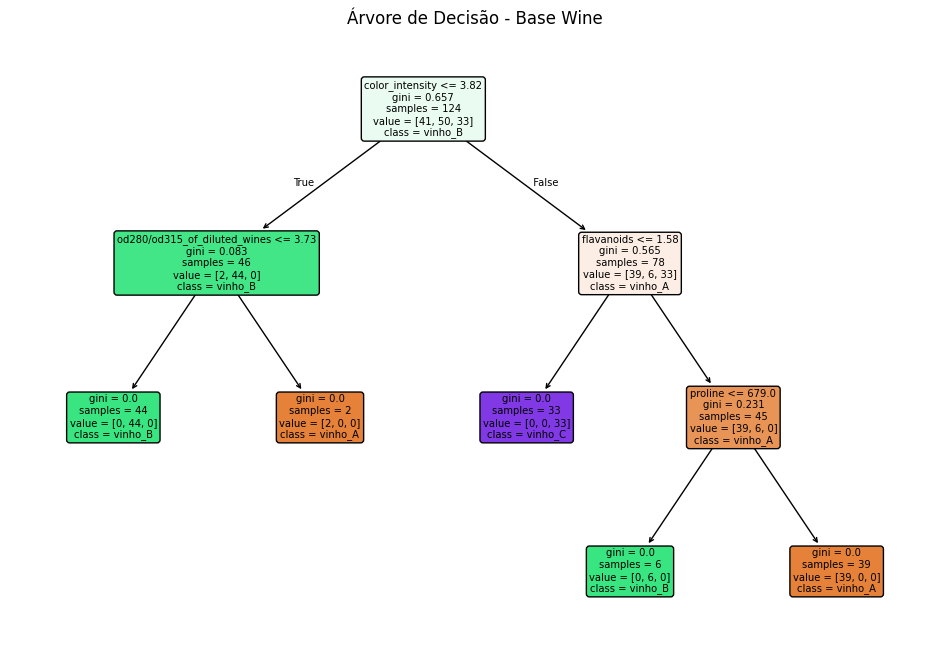

In [8]:
# Representação Gráfica da Árvore
gerar_grafico_da_arvore_de_decisao(clf, feature_names, target_names, 'Wine')
